# EDA of North Atlantic Basin part of ME4OH dataset - using SVD

Goal: To use SVD to reconstruct a low-rank approximation of OHC

In [1]:
import numpy as np
import pandas as pd

from plotting_functions import plot_ohc_map

## Load data

In [2]:
df = pd.read_csv("Data/ME4OH_EN411_OFAM3/NA_1993_2014.csv")

# Convert dates to datetime, save year month and year indication columns (aids plotting)
df['Date'] = pd.to_datetime(df['Date'])
df['year_month'] = df['Date'].dt.to_period('M')
df['year'] = df['Date'].dt.to_period('Y')
df

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number,year_month,year
0,1993-01-01,10.05,-27.950012,0.364007,-0.048830,401,WOD09XBTDE 329,14105829,1993-01,1993
1,1993-01-01,9.05,-28.350006,0.364593,-0.037233,401,WOD09XBTDE 329,14105829,1993-01,1993
2,1993-01-01,6.25,-31.350006,0.366382,0.043336,401,WOD09XBTPA 123,14302123,1993-01,1993
3,1993-01-01,56.55,-20.149994,0.356725,-0.522782,401,WOD09XBTGB 5966,11394866,1993-01,1993
4,1993-01-01,36.25,-8.549988,0.364267,-0.377209,401,WOD09XBT99,0,1993-01,1993
...,...,...,...,...,...,...,...,...,...,...
814193,2014-12-31,16.45,-78.350006,0.373563,0.350963,831,ARGOA,4902067,2014-12,2014
814194,2014-12-31,2.45,-25.149994,0.366325,0.030519,831,ARGOR,1901722,2014-12,2014
814195,2014-12-31,37.55,-68.950012,0.370469,0.210578,831,ARGOR,4901278,2014-12,2014
814196,2014-12-31,4.75,-27.350006,0.366465,0.026551,831,ARGOR,1901684,2014-12,2014


In [22]:
# Filter for a single month
df = df[df["year_month"]=="1993-01"]
df

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number,year_month,year
0,1993-01-01,10.05,-27.950012,0.364007,-0.048830,401,WOD09XBTDE 329,14105829,1993-01,1993
1,1993-01-01,9.05,-28.350006,0.364593,-0.037233,401,WOD09XBTDE 329,14105829,1993-01,1993
2,1993-01-01,6.25,-31.350006,0.366382,0.043336,401,WOD09XBTPA 123,14302123,1993-01,1993
3,1993-01-01,56.55,-20.149994,0.356725,-0.522782,401,WOD09XBTGB 5966,11394866,1993-01,1993
4,1993-01-01,36.25,-8.549988,0.364267,-0.377209,401,WOD09XBT99,0,1993-01,1993
...,...,...,...,...,...,...,...,...,...,...
1533,1993-01-31,6.05,-13.350006,0.365977,-0.005799,401,WOD09XBTFR 4293,11413493,1993-01,1993
1534,1993-01-31,20.65,-49.850006,0.372333,0.034181,401,WOD09XBTFR 4200,14108300,1993-01,1993
1535,1993-01-31,1.25,-22.250000,0.365645,-0.040895,401,WOD09XBTPA 121,14303521,1993-01,1993
1536,1993-01-31,8.65,-15.350006,0.365664,-0.025636,401,WOD09XBTFR 4293,11413493,1993-01,1993


In [23]:
# Create pivot table: rows = latitude, columns = longitude, values = OHC
matrix = df.pivot_table(index="Latitude", columns="Longitude", values="OHC")
matrix = matrix.fillna(0)  # Replace NaNs with 0
matrix

Longitude,-79.750000,-79.450012,-76.649994,-75.549988,-74.450012,-74.350006,-74.250000,-74.149994,-74.049988,-73.950012,...,-2.549988,-2.149994,-2.049988,-1.750000,-1.350006,-0.850006,-0.750000,-0.450012,-0.350006,-0.149994
Latitude,,,,,,,,,,,,,,,,,,,,,
0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57.35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Thoughts: some of these latitudes/longitudes are on land and therefore it is unrealistic to have an OHC value here

In [24]:
matrix.shape

(367, 455)

In [25]:
U, S, V = np.linalg.svd(matrix)
U.shape, S.shape, V.shape

((367, 367), (367,), (455, 455))

In [26]:
# Adjust matrix shapes to ensure U (m x n), S (n x n), V (n x n):
U = U[:, :S.shape[0]]  # Limit U to the number of singular values
S = np.diag(S)  # Convert S (a vector) into a diagonal matrix

In [27]:
S

array([[3.15808311e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.46086416e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.29773981e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.01706883e-16, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.88505256e-16, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.86755978e-16]], shape=(367, 367))

In [28]:
r = 5  # ??
R = U[:, :r] @ S[:r, :r] @ V[:r, :]  # Use rank-reduced components for approximation 
R

array([[ 8.42261153e-05,  8.81205996e-20,  2.67869606e-18, ...,
         1.14847133e-07,  8.05608382e-05, -2.16170112e-04],
       [ 7.68055254e-05, -3.15330080e-20,  2.40891980e-18, ...,
         1.19134185e-07,  7.32989841e-05,  3.48397561e-05],
       [ 1.03791640e-04, -1.10256932e-19,  2.84509503e-18, ...,
         5.66438822e-07,  9.51413551e-05, -3.17767500e-04],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.09388209e-06, -1.30592873e-20,  9.45979942e-20, ...,
         9.79521952e-08,  3.99271765e-06, -1.24182360e-04],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(367, 455))

In [29]:
R.shape

(367, 455)

In [30]:
reconstructed_df = pd.DataFrame(R, index=matrix.index.to_list(), columns=matrix.columns.to_list())

In [31]:
reconstructed_df = reconstructed_df.reset_index(drop=False, names='Latitude')
reconstructed_df

,Latitude,-79.75,-79.450012,-76.649994,-75.549988,-74.450012,-74.350006,-74.25,-74.149994,-74.049988,...,-2.549988,-2.149994,-2.049988,-1.75,-1.350006,-0.850006,-0.75,-0.450012,-0.350006,-0.149994
0,0.05,8.422612e-05,8.812060e-20,2.678696e-18,-3.680203e-05,8.016421e-05,2.619344e-04,-1.415107e-04,-2.665901e-04,-4.414850e-04,...,0.0,9.654750e-05,9.655425e-05,9.648937e-05,9.651423e-05,-2.162002e-04,-4.251438e-05,1.148471e-07,8.056084e-05,-2.161701e-04
1,0.15,7.680553e-05,-3.153301e-20,2.408920e-18,-3.489499e-06,7.293811e-05,2.411510e-04,-1.418791e-05,-2.659099e-05,1.193033e-05,...,0.0,8.972091e-05,8.972718e-05,8.966689e-05,8.968999e-05,3.484461e-05,-6.455785e-06,1.191342e-07,7.329898e-05,3.483976e-05
2,0.35,1.037916e-04,-1.102569e-19,2.845095e-18,-4.755178e-05,9.467294e-05,3.778787e-04,-1.890706e-04,-3.559426e-04,-6.195278e-04,...,0.0,1.605224e-04,1.605337e-04,1.604258e-04,1.604671e-04,-3.178117e-04,-5.960889e-05,5.664388e-07,9.514136e-05,-3.177675e-04
3,0.45,-1.640477e-19,-3.282045e-33,-4.462964e-33,5.974083e-19,-1.588543e-19,-4.721124e-19,2.319676e-18,4.374993e-18,8.538530e-18,...,0.0,-1.613222e-19,-1.613334e-19,-1.612250e-19,-1.612666e-19,4.843593e-18,7.882589e-19,-3.959734e-23,-1.596403e-19,4.842919e-18
4,0.55,-1.066970e-05,1.727226e-19,-1.414161e-20,-1.095406e-05,-7.486095e-06,-6.899589e-05,-3.738965e-05,-7.064003e-05,-1.261317e-04,...,0.0,-3.921820e-05,-3.922094e-05,-3.919459e-05,-3.920469e-05,-6.732647e-05,-7.066855e-06,-2.893497e-07,-7.523134e-06,-6.731710e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,56.85,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
363,57.35,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
364,57.45,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
365,57.55,5.093882e-06,-1.305929e-20,9.459799e-20,-1.619348e-05,3.973060e-06,2.751493e-05,-6.292853e-05,-1.185237e-04,-2.243075e-04,...,0.0,1.465366e-05,1.465469e-05,1.464484e-05,1.464861e-05,-1.241996e-04,-1.731853e-05,9.795220e-08,3.992718e-06,-1.241824e-04


In [32]:
unpivot_reconstruct = reconstructed_df.melt(id_vars='Latitude', var_name='Longitude', value_name='OHC')
unpivot_reconstruct

,Latitude,Longitude,OHC
0,0.05,-79.75,8.422612e-05
1,0.15,-79.75,7.680553e-05
2,0.35,-79.75,1.037916e-04
3,0.45,-79.75,-1.640477e-19
4,0.55,-79.75,-1.066970e-05
...,...,...,...
166980,56.85,-0.149994,0.000000e+00
166981,57.35,-0.149994,0.000000e+00
166982,57.45,-0.149994,0.000000e+00
166983,57.55,-0.149994,-1.241824e-04


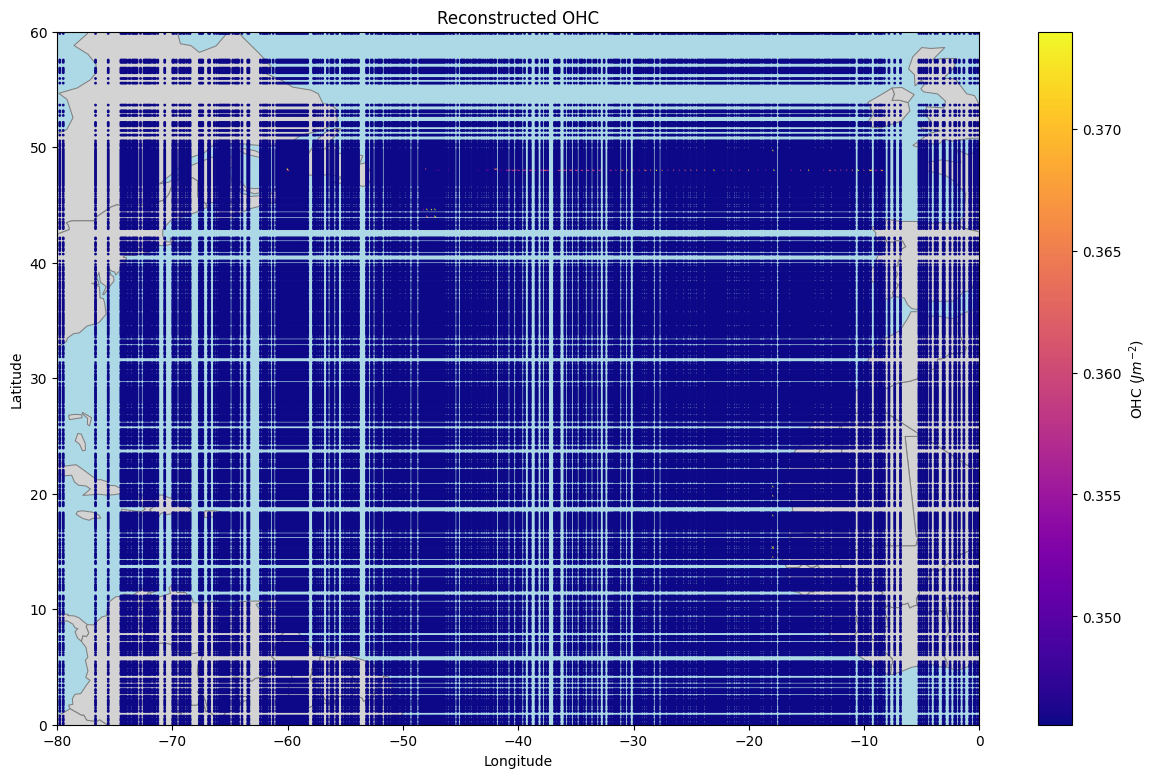

In [33]:
plot_ohc_map(unpivot_reconstruct, "Reconstructed OHC", min_ohc=min(df.OHC), max_ohc=max(df.OHC), basin="NA")